# Summary

04_real_example.ipynb

Single scan inference end-to-end. Load a scan, run NeuroFM.predict(), show the output brain health and latent features.

# Install

Unfortunately due to dependency conflicts between Tensorflow 2.13 and ipython, installation needs to take place outside the notebook in your ipykernel environment (unless you're running a kernel from the NeuroFM docker container, then you can skip this step).

Please run the following in your terminal Python environment before starting the kernel (mamba, etc.) to create and activate a dedicated environment, then install dependencies:
```bash
pip install "neurofm[notebooks] @ git+https://github.com/rockNroll87q/NeuroFM.git"
pip install templateflow==24.1.0 "numpy<=1.24.3" "typing-extensions<4.6.0"
```

**Note:** The `typing-extensions` pin is required for TensorFlow compatibility. Installing inside the notebook is not recommended as it conflicts with ipython's own dependencies. 


If you run into issues, we recommend using the NeuroFM notebook docker container `rocknroll87q/neurofm:notebook`:

Run: `docker run --rm -p 8888:8888 rocknroll87q/neurofm:notebook`.

Open your browser to `http://localhost:8888`.

# Prepare dataframes

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd


In [2]:
Path_in_analyses = Path('/work/data/NIFD/analyses/')

input_data = pd.read_csv(Path_in_analyses / 'nifd_filtered_qc.csv')
input_data['input'] = input_data['T1w_filenames']

def add_channel_suffix(path: str) -> str:
    """
    Inserts a channel suffix (e.g. _0000) before the .nii.gz (or .nii) extension.

    Args:
        path:    File path or filename ending in .nii.gz or .nii
        channel: Channel index (default 0 → _0000)

    Returns:
        Path with the channel suffix inserted before the extension.
    """
    suffix = "_256iso"
    new_path = re.sub(r"(\.nii(?:\.gz)?)$", rf"{suffix}\1", path)
    if new_path == path:
        raise ValueError(f"No .nii or .nii.gz extension found in: {path!r}")
    return new_path


input_data['input'] = input_data['input'].apply(add_channel_suffix)

input_data = input_data.sample(200)

input_data.to_csv(Path_in_analyses / 'nifd_filtered_qc-formatted.csv')

In [7]:
Path_out = Path_in_analyses / 'results'
Path_out.mkdir(parents=True, exist_ok=True)

# Run inference script

In [ ]:
!python ../scripts/run_inference.py -i /work/data/NIFD/analyses/nifd_filtered_qc-formatted.csv \
    -o /work/data/NIFD/analyses/results/ --device cpu --model neurofm-m --outputs brain_health,latent \
    --overwrite --verbose

# Process output files

In [12]:
results_dir = Path_in_analyses / 'results'

In [13]:
latents = np.load(results_dir / 'latent_embeddings.npy')
summary_df = pd.read_csv(results_dir / 'results_summary.csv')
latents_idx = pd.read_csv(results_dir / 'latent_embeddings_index.csv')

In [ ]:
latents_df = latents_idx.copy()

for idx in range(latents.shape[1]):
    col_name = f'z{idx}'
    latents_df[col_name] = latents[:, idx]

In [43]:
# make sure all absolute paths are resolved to properly match
abs_input_data = input_data.copy()
abs_input_data['input'] = abs_input_data['input'].apply(lambda old_path: str(Path(old_path).resolve()))

comb_df = abs_input_data.merge(latents_df, on='input', how='inner')
comb_df = comb_df.merge(summary_df, on='input', how='inner')
comb_df['BAG'] = comb_df['brain_age'] - comb_df['PatientAge']

# Visualize results

## Utility functions

In [46]:
import math

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from sklearn.manifold import TSNE


def plot_tsne(
    df: pd.DataFrame,
    embedding_cols: list,
    viz_cols: list,
    perplexity: int = 30,
    random_state: int = 42,
    figsize: tuple = (5, 4),
    ncols: int = 3,
) -> plt.Figure:
    """
    Fit a t-SNE on embedding_cols and plot one subplot per viz_col in a grid.
    Continuous columns use a colormap; categorical columns use discrete colors.

    Args:
        df:              Input DataFrame.
        embedding_cols:  Columns used as t-SNE input features.
        viz_cols:        Columns used to color the scatter points.
        perplexity:      t-SNE perplexity parameter.
        random_state:    Reproducibility seed.
        figsize:         (width, height) per subplot cell.
        ncols:           Number of columns in the grid.

    Returns:
        matplotlib Figure.
    """
    X = df[embedding_cols].to_numpy()
    coords = TSNE(
        n_components=2, perplexity=perplexity, random_state=random_state
    ).fit_transform(X)

    n = len(viz_cols)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize[0] * ncols, figsize[1] * nrows),
        squeeze=False,
    )

    for idx, col in enumerate(viz_cols):
        ax = axes[idx // ncols][idx % ncols]
        values = df[col]
        is_categorical = not pd.api.types.is_numeric_dtype(values)

        if is_categorical:
            categories = values.astype("category")
            codes = categories.cat.codes
            palette = cm.get_cmap("tab20", len(categories.cat.categories))
            ax.scatter(coords[:, 0], coords[:, 1], c=codes, cmap=palette,
                       s=15, alpha=0.7, linewidths=0)
            handles = [
                plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=palette(i), markersize=7, label=cat)
                for i, cat in enumerate(categories.cat.categories)
            ]
            ax.legend(handles=handles, title=col, bbox_to_anchor=(1.01, 1),
                      loc="upper left", fontsize=7, title_fontsize=8)
        else:
            norm = Normalize(vmin=values.min(), vmax=values.max())
            sc = ax.scatter(coords[:, 0], coords[:, 1], c=values, cmap="viridis",
                            norm=norm, s=15, alpha=0.7, linewidths=0)
            fig.colorbar(sc, ax=ax, label=col, shrink=0.8)

        ax.set_title(f"t-SNE — {col}", fontsize=10)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.set_xticks([])
        ax.set_yticks([])

    # hide any unused axes in the last row
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    return fig

## Visuals

Here we show some interesting visualization examples based on both the predicted brain health features (age, volume, etc.), and also the latent embeddings. 

Note that unlike in our paper, we are **not** correcting for QC-related artefacts in these predictions, which are highly correlated with diagnostic status in dementia. Even so, these serve as a visually interesting examples that may inspire your use-cases.

### t-SNE visuals

Below, we show a 2D t-SNE projection of the 200 random volumes, coloured by age, predicted brain, lateral ventricle volume, FTD diagnostic classification, and FTD subtype diagnostic classification, and brain age gap. We can see how the diagnostic groups are separating into distinct regions of the latent space. 

/var/folders/sj/4qrjl6ln4hs58lpkd69y4w940000gn/T/ipykernel_21450/1917348216.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab20", len(categories.cat.categories))
/var/folders/sj/4qrjl6ln4hs58lpkd69y4w940000gn/T/ipykernel_21450/1917348216.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab20", len(categories.cat.categories))


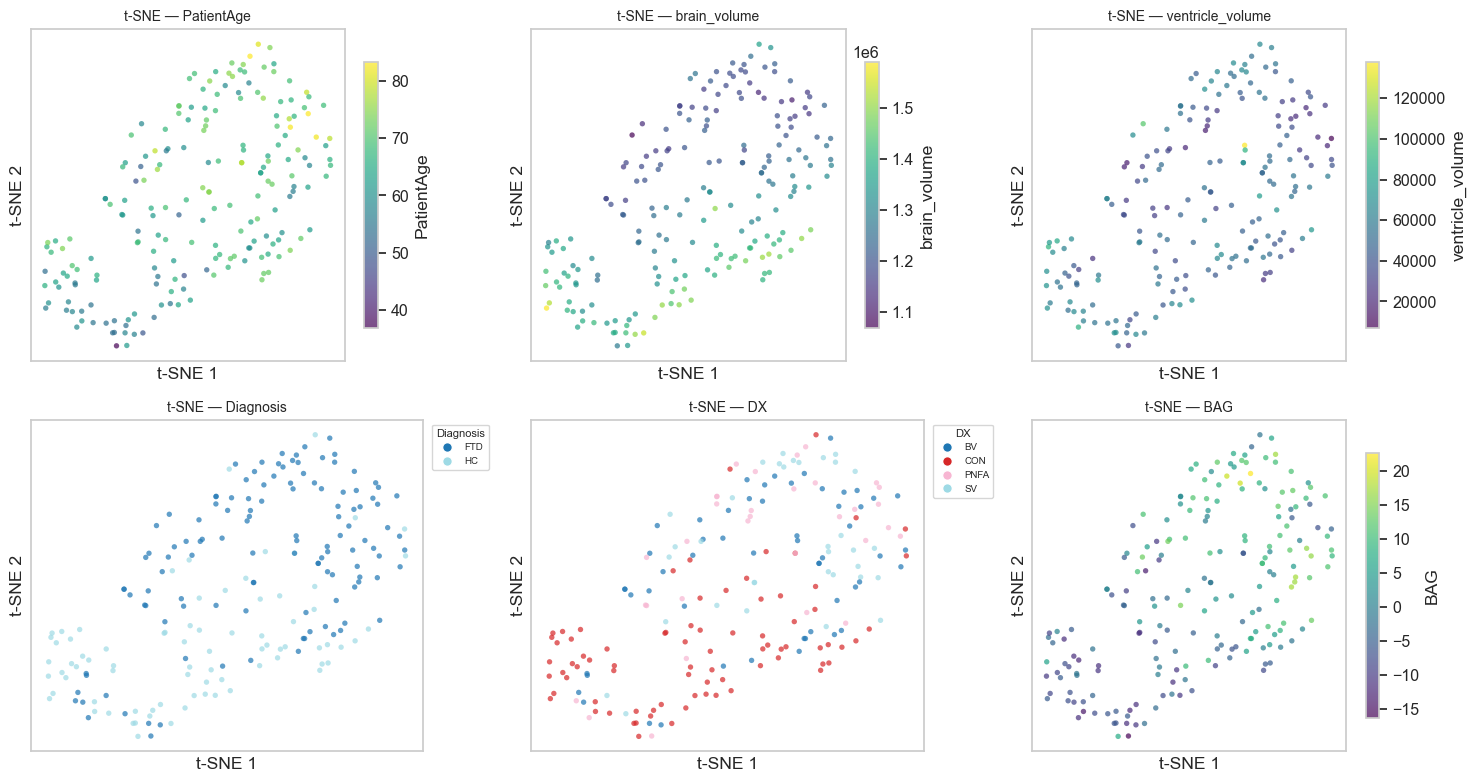

In [65]:
latent_cols = [col for col in list(comb_df.columns) if col.startswith("z")]

fig = plot_tsne(
    comb_df,
    embedding_cols=latent_cols,
    viz_cols=["PatientAge", "brain_volume", "ventricle_volume", "Diagnosis", "DX", "BAG"],
)

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Helpers & Theme colors

In [55]:
df = comb_df.copy()

In [58]:
sns.set_theme(style='whitegrid', font_scale=1.05)
BG       = '#F8F9FB'
DIAG_PAL = {'HC': '#4C9BE8', 'FTD': '#E8694C'}
DX_PAL   = {'CON': '#4C9BE8', 'PNFA': '#E8B84C', 'BV': '#E8694C', 'SV': '#9B4CE8'}
DX_ORDER = ['CON', 'PNFA', 'BV', 'SV']

def style_ax(ax, title, xlabel='', ylabel=''):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_edgecolor('#CCCCCC')

### Predicted vs Chronological age

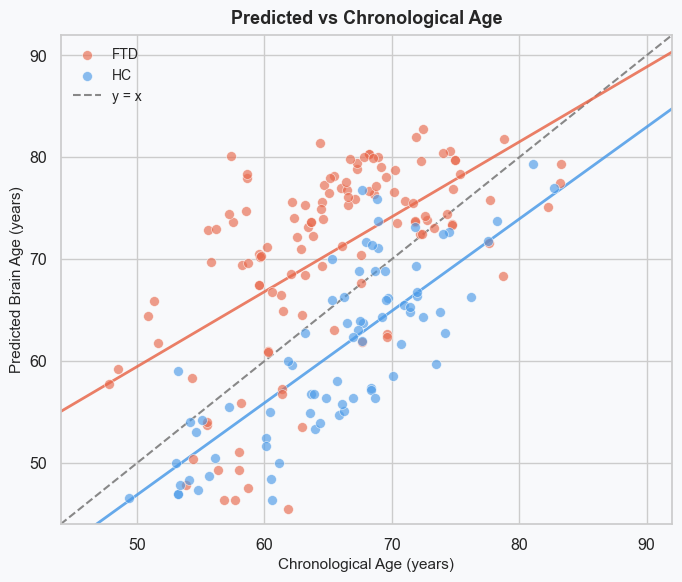

In [67]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)

for diag, grp in df.groupby('Diagnosis'):
    ax.scatter(grp.PatientAge, grp.brain_age,
               c=DIAG_PAL[diag], label=diag,
               alpha=0.65, edgecolors='white', linewidths=0.5, s=50, zorder=3)

lims = [44, 92]
ax.plot(lims, lims, '--', color='#888888', lw=1.5, label='y = x', zorder=2)

for diag, grp in df.groupby('Diagnosis'):
    m, b = np.polyfit(grp.PatientAge, grp.brain_age, 1)
    xs = np.array(lims)
    ax.plot(xs, m * xs + b, '-', color=DIAG_PAL[diag], lw=2, alpha=0.85)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend(frameon=False, fontsize=10)
style_ax(ax, 'Predicted vs Chronological Age',
         'Chronological Age (years)', 'Predicted Brain Age (years)')
fig.tight_layout()
plt.show()

### Brain age gap by diagnosis group

As expected, BAG increases significantly in diseased groups.

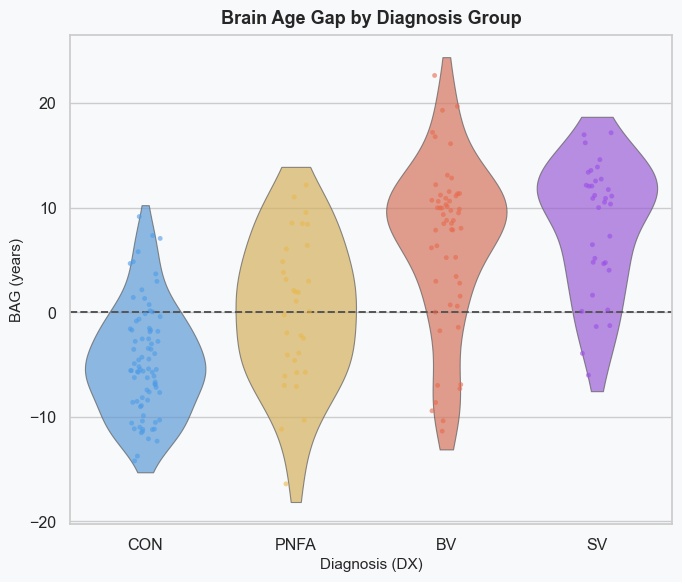

In [61]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)

sns.violinplot(data=df, x='DX', y='BAG', order=DX_ORDER,
               hue='DX', palette=DX_PAL, legend=False,
               inner=None, cut=0.5, linewidth=0.8, ax=ax, alpha=0.7)
sns.stripplot(data=df, x='DX', y='BAG', order=DX_ORDER,
              hue='DX', palette=DX_PAL, legend=False,
              size=3.5, alpha=0.6, jitter=True, ax=ax)
ax.axhline(0, color='#555555', lw=1.4, ls='--')
style_ax(ax, 'Brain Age Gap by Diagnosis Group', 'Diagnosis (DX)', 'BAG (years)')
fig.tight_layout()
plt.show()

### Brain volume vs ventricle volume

/var/folders/sj/4qrjl6ln4hs58lpkd69y4w940000gn/T/ipykernel_21450/933202150.py:11: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  fig.tight_layout()
/Users/austind/.local/share/mamba/envs/n3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


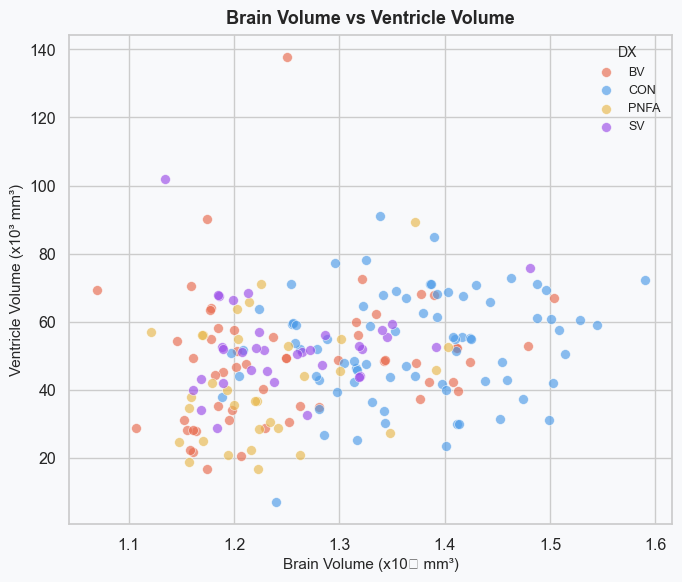

In [62]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)

for dx, grp in df.groupby('DX'):
    ax.scatter(grp.brain_volume / 1e6, grp.ventricle_volume / 1e3,
               c=DX_PAL[dx], label=dx,
               alpha=0.65, edgecolors='white', linewidths=0.5, s=50, zorder=3)

ax.legend(title='DX', frameon=False, fontsize=9, title_fontsize=10)
style_ax(ax, 'Brain Volume vs Ventricle Volume',
         'Brain Volume (x10⁶ mm³)', 'Ventricle Volume (x10³ mm³)')
fig.tight_layout()
plt.show()

### BAG distribution by diagnosis

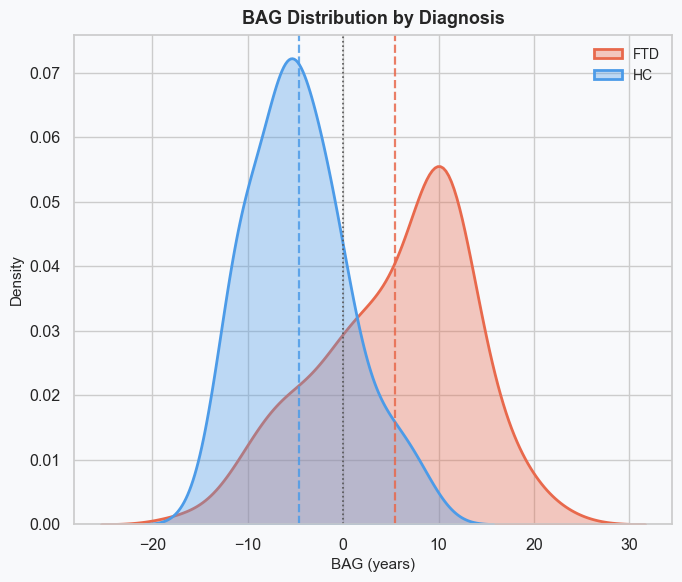

In [63]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)

for diag, grp in df.groupby('Diagnosis'):
    sns.kdeplot(grp.BAG, ax=ax, fill=True, color=DIAG_PAL[diag],
                label=diag, alpha=0.35, linewidth=2)
    ax.axvline(grp.BAG.mean(), color=DIAG_PAL[diag], ls='--', lw=1.6, alpha=0.85)

ax.axvline(0, color='#555555', lw=1.2, ls=':')
ax.legend(frameon=False, fontsize=10)
style_ax(ax, 'BAG Distribution by Diagnosis', 'BAG (years)', 'Density')
fig.tight_layout()
plt.show()